# Spotify Lab: Simple Vector Recommendations

**Name(s):**

You are a new data engineer at Spotify. When a listener asks for songs with similar content, we want to search a library of songs and return useful recommendations.

In this lab, every song is represented as a vector of lyric word counts. If the word "love" appears 12 times in a song, then the song has coordinate $x_{love}=12$ for that word. Songs with similar word-count patterns should have vectors that look similar.

The main files are:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the 800 word columns used in the vectors
- `./data/top_40_songs_by_genre.csv`: 40 popular songs from each genre, used as a benchmark

The genre labels are useful for evaluation, but they are not perfect ground truth. Some songs cross genres, some labels are debatable, and real recommendation systems would also use audio features, listener behavior, and human judgments.

The main idea of the lab:

**Dot product rewards shared word-count mass. Cosine similarity corrects for vector length. TF-IDF changes which words matter.**

## What You Will Submit

Complete the notebook and answer the yellow prompts in your own words. Your answers should focus on what each scoring rule rewards and whether the recommendations seem useful.

At the end, write a **short 2-4 paragraph report**. State which method you would recommend for this lyric-only prototype, use examples from the rankings, and explain one important limitation of using lyric word counts alone.

## Setup

We will use only `pandas`, `numpy`, and `seaborn`.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

songs = pd.read_csv("./data/song_vectors.csv.gz")
vocab = pd.read_csv("./data/vocabulary.csv")
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist()
meta_cols = [col for col in songs.columns if col not in word_cols]

X = songs[word_cols].to_numpy(dtype=float)

print("songs:", songs.shape)
print("word-count matrix:", X.shape)
print("top-40 benchmark:", top_40.shape)

songs: (8000, 816)
word-count matrix: (8000, 800)
top-40 benchmark: (560, 6)


In [4]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Inspect One Song Vector

Each row of `X` is one song vector. We will start with a single query song so the scoring rules are easier to see.

In [5]:
query_row = 0
query_track_id = songs.loc[query_row, "track_id"]
query = X[query_row]

songs.loc[[query_row], ["artist_name", "song_title", "genre", "n_words", "nnz_words"]]

,artist_name,song_title,genre,n_words,nnz_words
0,Gary Moore,What Are We Here For,blues,218,80


In [6]:
word_counts = pd.DataFrame({
    "word": word_cols,
    "count": query.astype(int),
})

word_counts.query("count > 0").sort_values("count", ascending=False).head(15)

,word,count
748,we,27
31,are,10
245,for,9
475,of,7
336,it,6
753,what,6
306,here,6
295,have,6
489,our,5
676,through,5


<div class="alert alert-block alert-warning">

What are the most common words in the query song? Do they look like words that would be useful for recommending similar songs? Why or why not?

</div>

The most common words start off with "we," "are," and "for." They do not look useful for recommending similar songs, as they do not seem like words that are related to any specific genres music types. Any songs would have these words.

## Part 2: Dot Product

The dot product is:

$$
x \cdot y = \sum_j x_j y_j
$$

It gets large when two songs use many of the same words many times. That can be useful, but it can also reward long or repetitive songs.

In [7]:
def top_matches(scores, query_track_id, k=10, query_artist_id=None):
    results = songs[meta_cols].copy()
    results["score"] = scores

    results = results[results["track_id"] != query_track_id]
    if query_artist_id is not None:
        results = results[results["artist_id"] != query_artist_id]

    return results.sort_values("score", ascending=False).head(k)

In [8]:
dot_scores = X @ query
dot_matches = top_matches(dot_scores, query_track_id, k=10)

dot_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

,artist_name,song_title,genre,n_words,score
1582,The Prodigy,We Gonna Rock,electronic,312,2136.0
6290,Lauryn Hill,Interlude 5,r&b/soul,1903,2115.0
5601,Bowling For Soup,Here We Go,punk,374,1939.0
1930,Ladyhawke,Crazy World,electronic,340,1680.0
6997,Ziggy Marley And The Melody Makers,We Propose,reggae,297,1656.0
3053,The Streets,Weak Become Heroes,hip hop,754,1654.0
2971,Black Eyed Peas,Communication,hip hop,592,1615.0
2874,Hollywood Undead,Undead,hip hop,831,1476.0
5840,Rise Against,Survive,punk,324,1383.0
3085,Binary Star,Indy 500,hip hop,977,1331.0


In [9]:
tgt_row = 1582
tgt_track_id = songs.loc[tgt_row, "track_id"]
tgt = X[tgt_row]

songs.loc[[tgt_row], ["artist_name", "song_title", "genre", "n_words", "nnz_words"]]

,artist_name,song_title,genre,n_words,nnz_words
1582,The Prodigy,We Gonna Rock,electronic,312,10


In [10]:
tgt_word_counts = pd.DataFrame({
    "word": word_cols,
    "count": tgt.astype(int),
})

tgt_word_counts.query("count > 0").sort_values("count", ascending=False).head(15)

,word,count
272,gonna,78
748,we,78
556,rock,78
123,come,30
480,on,30
372,like,3
671,this,3
788,yall,3
667,these,1


[Text(0.5, 1.0, 'Dot product top matches'),
 Text(0.5, 0, 'dot product'),
 Text(0, 0.5, '')]

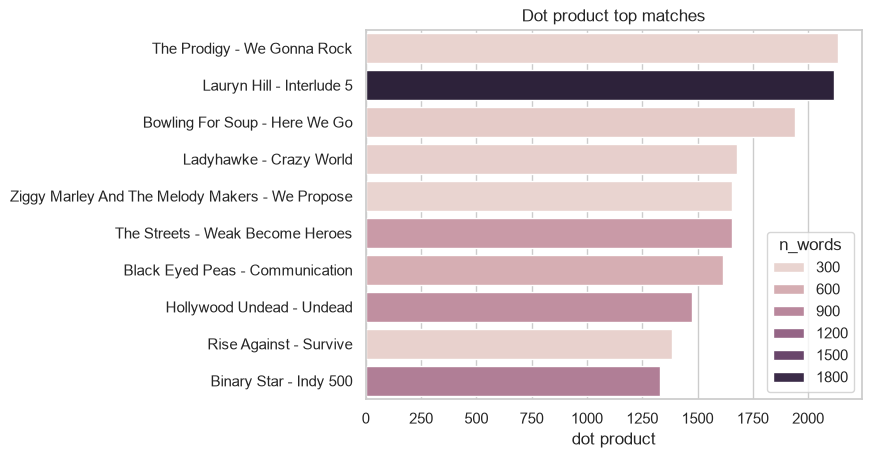

In [11]:
plot_data = dot_matches.copy()
plot_data["song"] = plot_data["artist_name"] + " - " + plot_data["song_title"]

ax = sns.barplot(data=plot_data, y="song", x="score", hue='n_words')
ax.set(title="Dot product top matches", xlabel="dot product", ylabel="")

<div class="alert alert-block alert-warning">

Look at the dot-product matches. Do they seem similar to the query song, or does the score seem to reward song size/repetition? Use at least one specific song from the table in your answer.

Query song is: Gary Moore - What Are We Here For.Category of the query song is blues
- First recommended song is: The Prodigy - We Gonna Rock, which is an electronic song. This suggests that songs with similiar words might not actually sound similiar, or be in a similiar category. Upon further observation, We Gonna Rock says the word we 78 times, and What Are We Here For says 'we' 27 times, so this accounts for 27*78=2106 of the similarity, which is almost all of it.
- Second recommended song is: Lauryn Hill - Interlude 5. This song has way more words than any other song on the list. By sheer volume of its words, it is likely to have a lot in common with the Gary Moore song.
- The third recommendation: Bowling for Soup - Here we Go. Punk song, suggests (like the first song) that songs can have similiar words without actually sharing their genre.

</div>

## Part 3: Cosine Similarity

Cosine similarity divides the dot product by the lengths of the two vectors:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

This compares the direction of the word-count profiles. A long song does not automatically win just because it has more words.

In [12]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    denominators = np.linalg.norm(matrix, axis=1) * np.linalg.norm(query_vector)

    return np.divide(
        numerators,
        denominators,
        out=np.zeros(len(numerators)),
        where=denominators != 0,
    )

In [13]:
cos_scores = cosine_scores(X, query)
cos_matches = top_matches(cos_scores, query_track_id, k=10)

cos_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

,artist_name,song_title,genre,n_words,score
6997,Ziggy Marley And The Melody Makers,We Propose,reggae,297,0.761523
4677,Modern Life Is War,Destination: Death or Better Days,metal,204,0.755322
4933,EDGUY,Superheroes,metal,191,0.735159
4489,Raised Fist,Soldiers Of Today,metal,222,0.707435
4521,Lifetime,Daneurysm,metal,68,0.703254
4550,Tourniquet,Convoluted Absolutes,metal,189,0.696703
5831,Street Dogs,Free,punk,291,0.696275
4896,Arsonists Get All The Girls,Tourtasia,metal,195,0.692076
5184,Thompson Twins,We Are Detective,pop,172,0.689013
5921,Dead Kennedys,Goons of Hazzard,punk,196,0.687867


[Text(0.5, 1.0, 'Cosine similarity top matches'),
 Text(0.5, 0, 'cosine similarity'),
 Text(0, 0.5, '')]

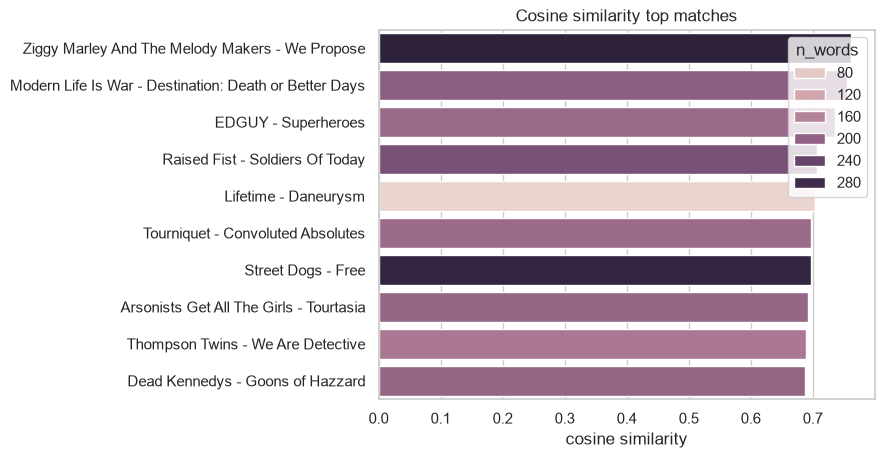

In [14]:
plot_data = cos_matches.copy()
plot_data["song"] = plot_data["artist_name"] + " - " + plot_data["song_title"]

ax = sns.barplot(data=plot_data, y="song", x="score", hue='n_words')
ax.set(title="Cosine similarity top matches", xlabel="cosine similarity", ylabel="")

In [15]:
dot_v_cos_words = pd.DataFrame({
    "dot": dot_matches["n_words"],
    "cos": cos_matches["n_words"],
})

dot_v_cos_words.describe()

,dot,cos
count,10.000000,10.000000
mean,670.400000,202.500000
std,498.567102,63.751688
min,297.000000,68.000000
25%,328.000000,189.500000
50%,483.000000,195.500000
75%,811.750000,217.500000
max,1903.000000,297.000000


In [16]:
tgt_row = 6997
tgt_track_id = songs.loc[tgt_row, "track_id"]
tgt = X[tgt_row]

songs.loc[[tgt_row], ["artist_name", "song_title", "genre", "n_words", "nnz_words", 'top_tags']]

tgt_word_counts = pd.DataFrame({
    "word": word_cols,
    "count": tgt.astype(int),
})


tgt_df = tgt_word_counts.query("count > 0").sort_values("count", ascending=False).head(10)
query_df = word_counts.query("count > 0").sort_values("count", ascending=False).head(10)

tgt_df
query_df
pd.merge(tgt_df, query_df, on="word", how="outer", suffixes=("_tgt", "_query")).fillna(0).sort_values("count_tgt", ascending=False)

,word,count_tgt,count_query
14,we,47.0,27.0
7,learn,21.0,0.0
0,are,13.0,10.0
13,tire,8.0,0.0
8,of,8.0,7.0
10,peopl,7.0,0.0
11,this,6.0,0.0
5,is,6.0,0.0
16,yeah,6.0,0.0
2,free,5.0,0.0


<div class="alert alert-block alert-warning">

Compare the dot-product matches to the cosine matches. Which method looks more like a similar-song engine? Which method looks more like it is rewarding raw word-count mass?

* The cosine matches seem to be better (still not great). The top song is We Propose by Ziggy Marley And The Melody Makers, which is raggae. It says 'We' 47 times (query says it 27), 'are' 13 times (query says it 10 times), and 'of' 8 times (query says it 7). Did a better job aligning words, but songs still seem different.
* Mean number of words in the dot matches is 670 (median 483), and mean number of words in cosine matches is 202 (median 195.5), therefore it looks like dot-matches favors raw word count mass.

</div>

## Part 4: TF-IDF

Some words appear in many songs. Those words can dominate similarity scores even if they do not tell us much about the song.

TF-IDF changes the word-count matrix in two steps:

1. **Term frequency:** `np.log1p(X)` makes each additional repeated use of a word count less than the previous one. This reduces the marginal effect of repetition within a song.
2. **Inverse document frequency:** words that appear in many songs get smaller weights, and words that appear in fewer songs get larger weights.

Then we use the transformed matrix for recommendations.

In [17]:
TF = np.log1p(X)

document_frequency = (X > 0).sum(axis=0)
IDF = np.log(len(songs) / document_frequency)

TFIDF = TF * IDF

idf_table = pd.DataFrame({
    "word": word_cols,
    "document_frequency": document_frequency,
    "idf": IDF,
})

In [18]:
idf_table.sort_values("idf").head(10)

,word,document_frequency,idf
324,i,5966,0.293365
22,and,5960,0.294371
795,you,5671,0.344076
409,me,5420,0.389346
331,in,5345,0.403280
334,is,5191,0.432515
336,it,5045,0.461044
466,not,4961,0.477834
475,of,4785,0.513956
662,that,4597,0.554038


In [19]:
idf_table.sort_values("idf", ascending=False).head(10)

,word,document_frequency,idf
176,doo,26,5.729100
258,funk,48,5.115996
726,ven,56,4.961845
327,ihr,59,4.909659
770,wir,60,4.892852
201,er,63,4.844062
711,u,66,4.797542
162,dich,68,4.767689
596,sie,78,4.630488
208,eu,81,4.592748


<div class="alert alert-block alert-warning">

What do you notice about the lowest-IDF words and highest-IDF words? Why might this matter for a recommendation system?
* Lowest-IDF words are basic words used to construct English sentences. They are not unique, they are very common, and they do not contribute much in terms of content to a sentence.
* Highest-IDF words are really uncommon, some of which are not even real words (to my understanding). They also seem to not contribute content, but might be more 'niche'.
* Higher-IDF words are more 'niche', meaning they are less common, and so the presence of relatively many uncommon words in two seperate songs gives a stronger signal to similarity. This helps to solve the issue we have been dealing with so far where basic english constructor words (like 'we') are over-represented in the recommended song. Also, it allows for words with actual meaning, that will be less common, to have a stronger effect on the model.

</div>

In [20]:
query_tfidf = TFIDF[query_row]

tfidf_dot_scores = TFIDF @ query_tfidf
tfidf_dot_matches = top_matches(tfidf_dot_scores, query_track_id, k=10)

tfidf_dot_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

,artist_name,song_title,genre,n_words,score
6290,Lauryn Hill,Interlude 5,r&b/soul,1903,266.908244
2659,Eminem,8 Mile,hip hop,1141,192.153763
3252,Kurt Elling,Resolution,jazz,605,172.069225
4419,Savatage,The Hourglass,metal,889,169.770168
2691,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,hip hop,1746,163.961655
4547,Pain of Salvation,Kingdom of Loss,metal,498,154.080568
6688,Prince,I Love U In Me ( LP Version),r&b/soul,680,150.685461
4654,Set Your Goals,our ethos: a legacy to pass on,metal,418,149.919458
2991,Binary Star,Honest Expression,hip hop,933,146.504872
3161,Murs,The Dance,hip hop,913,141.616639


In [21]:
tfidf_cos_scores = cosine_scores(TFIDF, query_tfidf)
tfidf_cos_matches = top_matches(tfidf_cos_scores, query_track_id, k=10)

tfidf_cos_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

,artist_name,song_title,genre,n_words,score
4654,Set Your Goals,our ethos: a legacy to pass on,metal,418,0.327636
4547,Pain of Salvation,Kingdom of Loss,metal,498,0.311372
1094,Blue Rodeo,Love And Understanding,country,211,0.294766
3252,Kurt Elling,Resolution,jazz,605,0.288733
6290,Lauryn Hill,Interlude 5,r&b/soul,1903,0.288405
4777,Soulfly,One Nation (Album Version),metal,278,0.286295
2739,Hieroglyphics,You Never Knew,hip hop,439,0.286245
6161,Michelle Williams,The Greatest,r&b/soul,301,0.285134
4945,Frantic Bleep,Cone,metal,42,0.283387
1991,Enigma,Out From The Deep,electronic,123,0.278396


<Axes: >

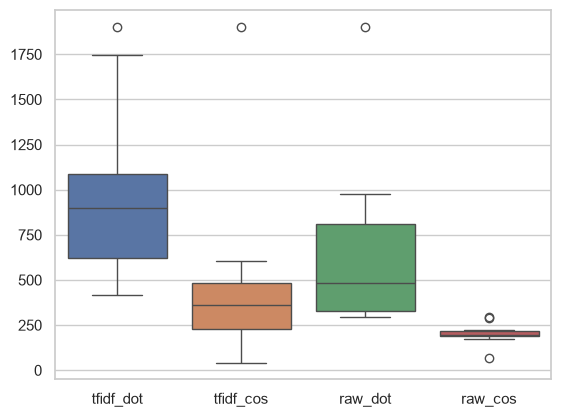

In [22]:
tfidf_raw_combined_nwords = pd.DataFrame({
    "tfidf_dot": tfidf_dot_matches["n_words"],
    "tfidf_cos": tfidf_cos_matches["n_words"],
    "raw_dot": dot_matches["n_words"],
    "raw_cos": cos_matches["n_words"]})

tfidf_raw_combined_nwords.describe()

sns.boxplot(data=tfidf_raw_combined_nwords)


In [23]:
tfidf_dot_matches['genre'].value_counts()

genre
hip hop     4
metal       3
r&b/soul    2
jazz        1
Name: count, dtype: int64

In [24]:
all_genres = pd.DataFrame({
    "tfidf_dot": tfidf_dot_matches["genre"].value_counts(),
    "tfidf_cos": tfidf_cos_matches["genre"].value_counts(),
    "raw_dot": dot_matches["genre"].value_counts(),
    "raw_cos": cos_matches["genre"].value_counts()})

all_genres

,tfidf_dot,tfidf_cos,raw_dot,raw_cos
genre,,,,
country,NaN,1.0,NaN,NaN
electronic,NaN,1.0,2.0,NaN
hip hop,4.0,1.0,4.0,NaN
jazz,1.0,1.0,NaN,NaN
metal,3.0,4.0,NaN,6.0
pop,NaN,NaN,NaN,1.0
punk,NaN,NaN,2.0,2.0
r&b/soul,2.0,2.0,1.0,NaN
reggae,NaN,NaN,1.0,1.0


<div class="alert alert-block alert-warning">

Compare raw dot product, raw cosine, TF-IDF dot product, and TF-IDF cosine. Which recommendation list seems best for this query song? Give one specific example.

* In terms of song lengths, raw dot/cosine actually recommend songs that are shorter on average when compared to their tf-idf counterparts. Between dot and cos, dot consistently recommends longer songs.
* query song is classified as blues, so it is reasonable to assume that the best recommendations are the ones with genres 'closest' to blues. I would suggest genres like country, electronic, and metal are 'the most' not similiar, and that genres like jazz, r&b/soul, and reggae are the 'most' similiar. With this criteria, both tfidf lists compare equally (3 in this bucket). But, because of dots tendency to favor song length, I would argue that tfidf_cos is the best function

</div>

## Part 5: Benchmark with Genre

Evaluate all four methods on the Top-40 songs.

For each query song, we will:

1. score every possible match,
2. remove the query song itself,
3. remove songs by the same artist,
4. keep the top two matches,
5. record whether each match has the same genre as the query.

The final score is **precision@2**: the share of recommendation slots that match the query genre.

In [25]:
top_40

,track_id,song_id,artist_id,artist_name,song_title,genre
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues
...,...,...,...,...,...,...
555,TRUIAKW128F428C787,SOKFHMY12A8C13EB40,AR16GSC1187B9A6291,Eagles,It's Your World Now,rock
556,TRCRHFK128F427FD8F,SOLBZDL12CF5F88BE5,AR5FP401187FB523C9,Bob Dylan,Something There Is About You,rock
557,TRMOUUU128F14ADE16,SOJFEHH12A6BD546BE,ART1UFU1187FB4C9B6,Hawk Nelson,From Underneath,rock
558,TRCURQD128F427C75B,SORFOFF12A8C13B65E,ART1UFU1187FB4C9B6,Hawk Nelson,Turn It On,rock


In [26]:
top_40_track_id = top_40["track_id"].tolist()
track = top_40_track_id[0]

query_idx = songs.loc[songs["track_id"] == track].index[0]
songs.loc[[query_idx], ["artist_name", "song_title", "genre", "n_words", "nnz_words"]]


,artist_name,song_title,genre,n_words,nnz_words
477,Michael Jackson,All The Things You Are,blues,172,43


In [27]:
# Test block for one query and one method

# query = X[query_idx]
# dot_scores = X @ query
# dot_matches = top_matches(dot_scores, query_track_id, k=10)
# # Functions already remove the query track
# # Remove if artist is the same as the query artist
# dot_matches.drop(dot_matches[dot_matches["artist_id"] == songs.loc[query_idx, "artist_id"]].index, inplace=True)
# # Keep only top 2 matches
# dot_matches = dot_matches.head(2)
# # Record if match has same genre as query
# same_genre = dot_matches["genre"] == songs.loc[query_idx, "genre"]
# # Share of recommendations that match query genre
# match_rate = same_genre.mean()

In [28]:
top_40_track_id = top_40["track_id"].tolist()
dot_match_rates = []
cos_match_rates = []
tfidf_dot_match_rates = []
tfidf_cos_match_rates = []

for track in top_40_track_id:
    # setup query vector for this track
    query_idx = songs.loc[songs["track_id"] == track].index[0]
    query = X[query_idx]

    # dot product matches
    dot_scores = X @ query
    dot_matches = top_matches(dot_scores, track, k=10)

    # cosine similarity matches
    cos_scores = cosine_scores(X, query)
    cos_matches = top_matches(cos_scores, track, k=10)

    # tfidf dot product matches
    query_tfidf = TFIDF[query_idx]
    tfidf_dot_scores = TFIDF @ query_tfidf
    tfidf_dot_matches = top_matches(tfidf_dot_scores, track, k=10)

    # tfidf cosine similarity matches
    tfidf_cos_scores = cosine_scores(TFIDF, query_tfidf)
    tfidf_cos_matches = top_matches(tfidf_cos_scores, track, k=10)

    # Drop if artist is the query artist
    dot_matches.drop(dot_matches[dot_matches["artist_id"] == songs.loc[query_idx, "artist_id"]].index, inplace=True)
    cos_matches.drop(cos_matches[cos_matches["artist_id"] == songs.loc[query_idx, "artist_id"]].index, inplace=True)
    tfidf_dot_matches.drop(tfidf_dot_matches[tfidf_dot_matches["artist_id"] == songs.loc[query_idx, "artist_id"]].index, inplace=True)
    tfidf_cos_matches.drop(tfidf_cos_matches[tfidf_cos_matches["artist_id"] == songs.loc[query_idx, "artist_id"]].index, inplace=True)

    # Keep only top 2 matches
    dot_matches = dot_matches.head(2)
    cos_matches = cos_matches.head(2)
    tfidf_dot_matches = tfidf_dot_matches.head(2)
    tfidf_cos_matches = tfidf_cos_matches.head(2)

    # Record if mtch has same genre as query
    same_genre_dot = dot_matches["genre"] == songs.loc[query_idx, "genre"]
    same_genre_cos = cos_matches["genre"] == songs.loc[query_idx, "genre"]
    same_genre_tfidf_dot = tfidf_dot_matches["genre"] == songs.loc[query_idx, "genre"]
    same_genre_tfidf_cos = tfidf_cos_matches["genre"] == songs.loc[query_idx, "genre"]

    # Append rate to respective list
    dot_match_rates.append(same_genre_dot.mean())
    cos_match_rates.append(same_genre_cos.mean())
    tfidf_dot_match_rates.append(same_genre_tfidf_dot.mean())
    tfidf_cos_match_rates.append(same_genre_tfidf_cos.mean())

    

In [29]:
summary_df = pd.DataFrame({
    "dot": dot_match_rates,
    "cos": cos_match_rates,
    "tfidf_dot": tfidf_dot_match_rates,
    "tfidf_cos": tfidf_cos_match_rates
})
summary_df.describe()

,dot,cos,tfidf_dot,tfidf_cos
count,560.000000,560.000000,560.000000,560.000000
mean,0.082143,0.195536,0.102679,0.205357
std,0.194841,0.323052,0.240549,0.316182
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.500000,0.000000,0.500000
max,1.000000,1.000000,1.000000,1.000000


<div class="alert alert-block alert-warning">

Which method has the best precision@2? Does that agree with your judgment from the single-query examples, or does the benchmark change your view?
* tf-df_cos has the best precision@2. This is in agreement with my judgement from single-query examples. However, it is closer to the regular cosine similarity function then I would have expected.


</div>

## Part 6: Test an Adjustment

A recommendation system is a design choice. Investigate your previous results, think of a promising change to make in the system, and compare it to the pevious methods. Did the adjustment improve results? (It's fine if it didn't.)

In [30]:
# # My new method. Cosine similarity while removing the top 20 tfidf words from the query vector.
# def cosine_scores(matrix, query_vector):
#     query_vector_removed = query_vector
#     numerators = matrix @ query_vector
#     denominators = np.linalg.norm(matrix, axis=1) * np.linalg.norm(query_vector)

#     return np.divide(
#         numerators,
#         denominators,
#         out=np.zeros(len(numerators)),
#         where=denominators != 0,
#     )



Instead of counting how many times a song uses each word, we just record whether it was used at all. Since earlier scores are heavily impacted by repetition, we are removing this effect entirely.

In [37]:
def precision_at_2(M, use_cosine=True):
    rates = []
    for track in top_40_track_id:
        i = songs.loc[songs["track_id"] == track].index[0]
        if use_cosine:
            scores = cosine_scores(M, M[i])
        else:
            scores = M @ M[i]
        matches = top_matches(scores, track, 2, songs.loc[i, "artist_id"])
        rates.append((matches["genre"] == songs.loc[i, "genre"]).mean())
    return np.mean(rates)

binary = (X > 0).astype(float)

comparison = pd.DataFrame({
    "method": ["dot", "cosine", "tfidf_dot", "tfidf_cosine", "cosine binary"],
    "precision@2": [
        precision_at_2(X, use_cosine=False),
        precision_at_2(X),
        precision_at_2(TFIDF, use_cosine=False),
        precision_at_2(TFIDF),
        precision_at_2(binary),
    ],
})

print(comparison.to_string(index=False))

       method  precision@2
          dot     0.082143
       cosine     0.195536
    tfidf_dot     0.102679
 tfidf_cosine     0.205357
cosine binary     0.240179


## Final Report

Write a short report on your results in a document file:

1. Which method would you recommend for this lyric-only prototype?
2. What evidence from the tables or precision@2 scores supports your choice?
3. Give at least two concrete song examples from the recommendations.
4. What is one important limitation of lyric word counts alone? What other data would be helpful, and how would you use it?